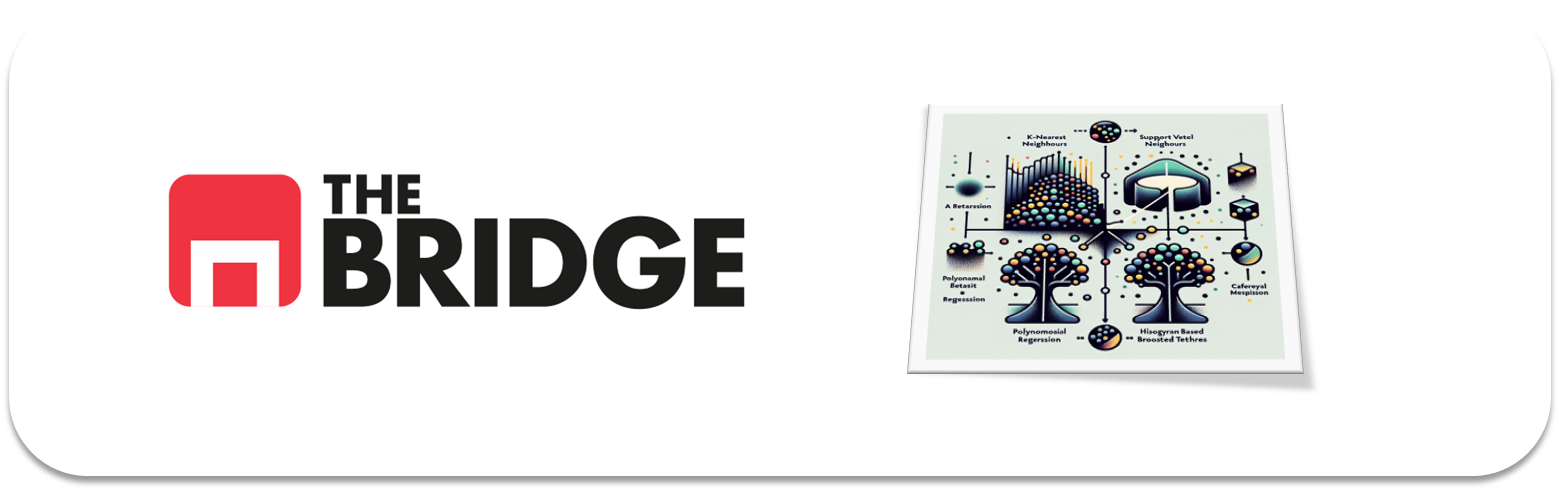

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bootcampviztools as bt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier, LGBMRegressor
from xgboost import XGBClassifier, XGBRegressor

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, mean_absolute_percentage_error

pd.options.mode.copy_on_write = True

### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

In [18]:
df = pd.read_csv("./data/wines_dataset.csv", sep="|")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.16,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.18,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.26,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.63,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


- 11 numéricas continuas (float64) → las propiedades químicas del vino
- 1 numérica discreta (int64) → quality (puntuación 0-10)
- 1 categórica (object) → class (blanco o tinto)

In [20]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [21]:
print(df["class"].value_counts())

class
white    4898
red      1599
Name: count, dtype: int64


In [22]:
target_clf = "quality"      # Para clasificación
target_reg = "alcohol"      # Para regresión

print("Distribución de quality:")
print(df[target_clf].value_counts().sort_index())

Distribución de quality:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


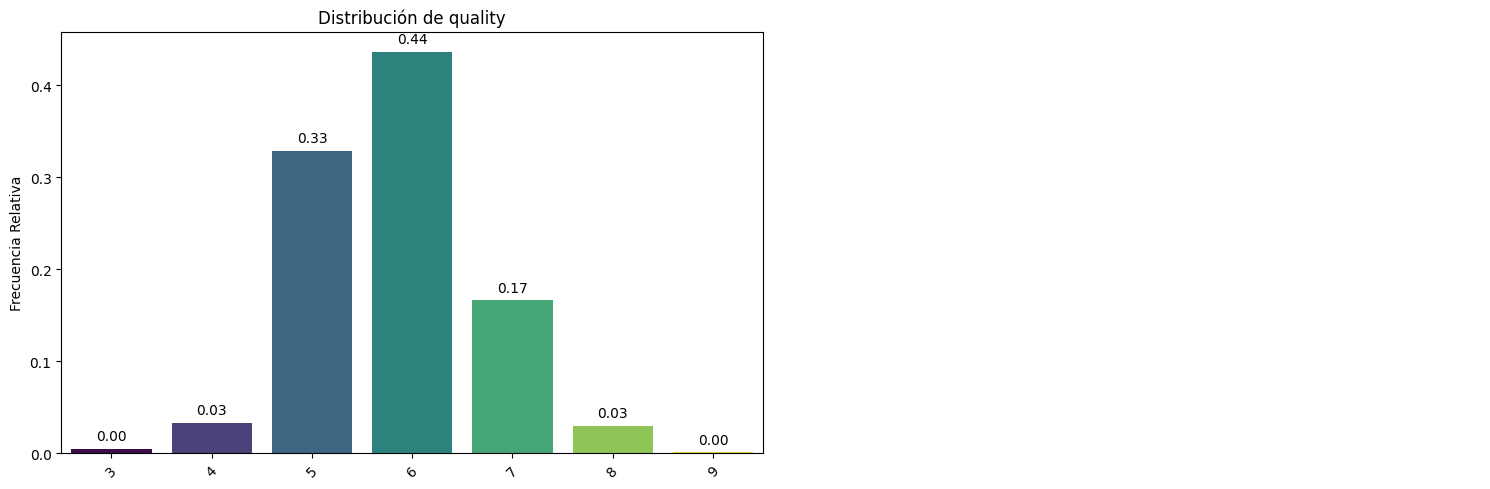

In [23]:
# Distribución del target de clasificación
bt.pinta_distribucion_categoricas(df, [target_clf], mostrar_valores=True, relativa=True)

- Las clases 5 y 6 dominan (33% y 44%)
- Las clases extremas 3, 4, 8 y 9 tienen muy pocos datos
- Este es un problema multiclase muy desbalanceado

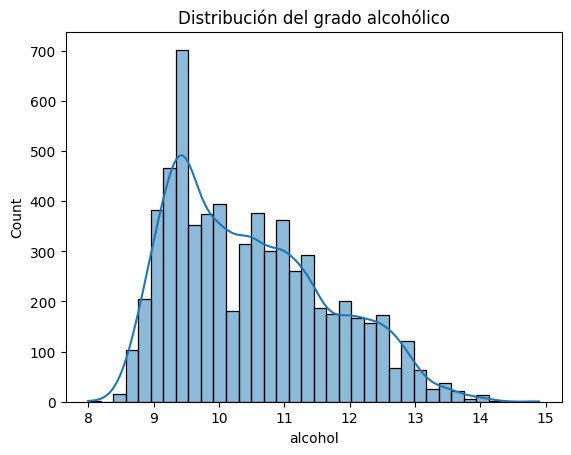

In [24]:
# Distribución del target de regresión
sns.histplot(df[target_reg], kde=True)
plt.title("Distribución del grado alcohólico")
plt.show()

- La mayoría de vinos tienen entre 9 y 13 grados
- Tiene una distribución con cola a la derecha 

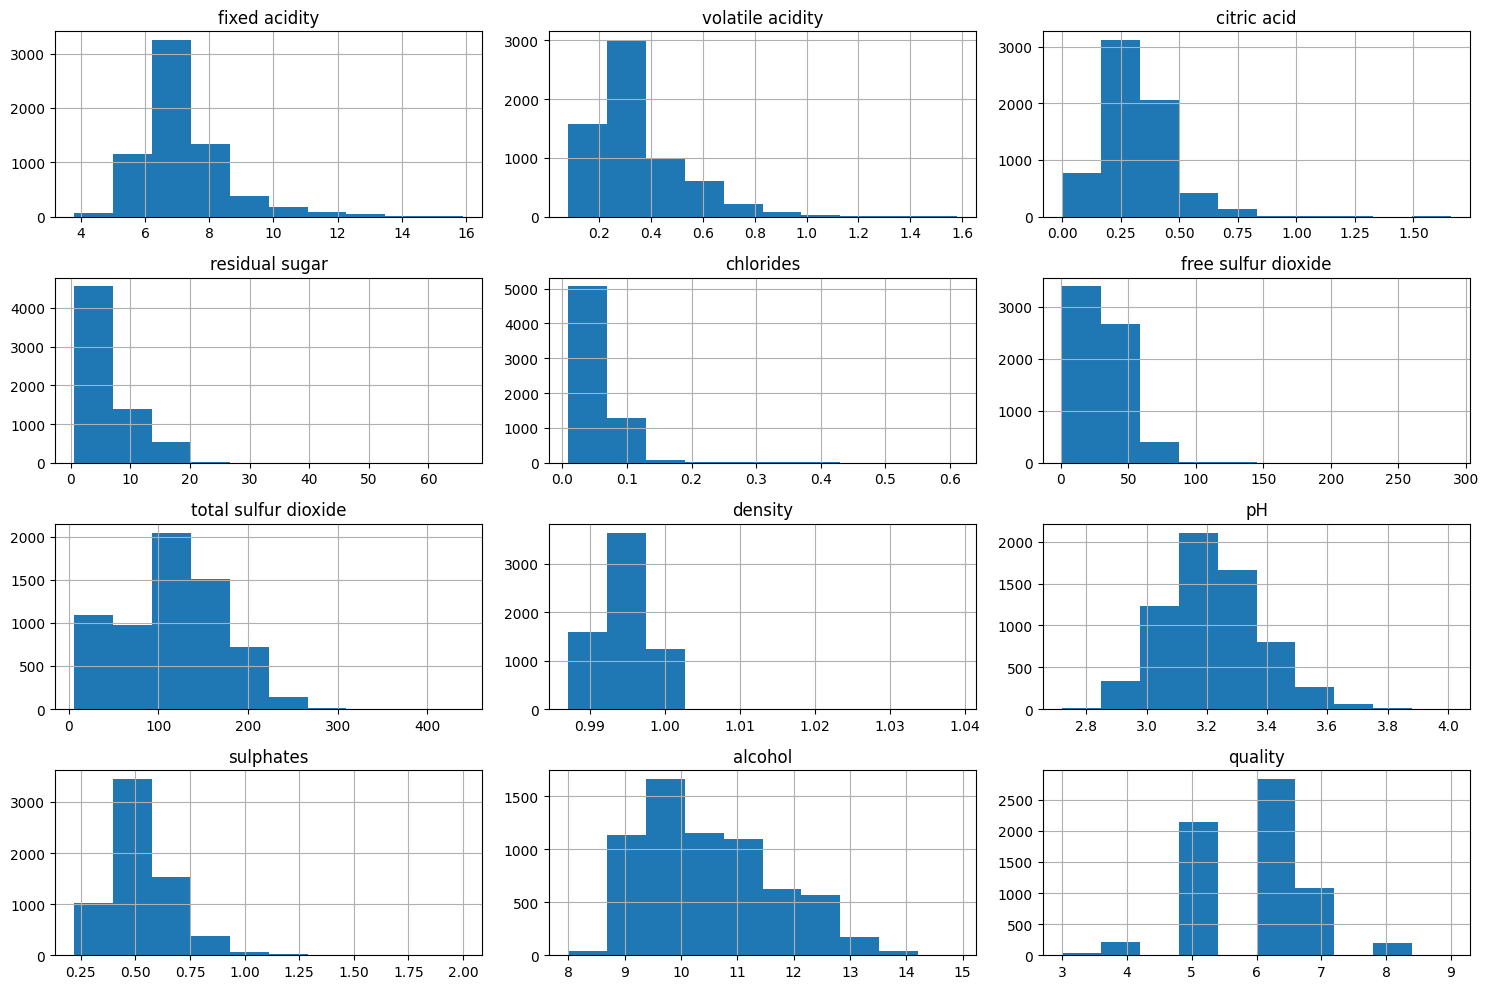

In [25]:
#Histogramas de las variables
df.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

- fixed acidity: concentrada entre 5-8, con cola a la derecha
- volatile acidity: concentrada en valores bajos (0.2-0.4), valores altos indican sabor a vinagre
- citric acid: mayoría entre 0-0.5, distribución sesgada
- residual sugar: muy concentrada en valores bajos,con outliers extremos (algunos vinos muy dulces)
- chlorides: casi todos los vinos tienen poca sal,con algunos outliers altos
- free y total sulfur dioxide: colas largas a la derecha,necesitarán transformación logarítmica para escalar bien
- density: muy concentrada alrededor de 0.995-1.000
- pH: distribución bastante normal entre 3.0 y 3.5
- sulphates: concentrada en valores bajos con outliers
- alcohol: entre 8 y 15 grados, pico en 9-10 grados
- quality: desbalanceada, dominan las clases 5 y 6

In [37]:
print(df[target_clf].value_counts(normalize=True).round(3) * 100)

quality
6    43.7
5    32.9
7    16.6
4     3.3
8     3.0
3     0.5
9     0.1
Name: proportion, dtype: float64


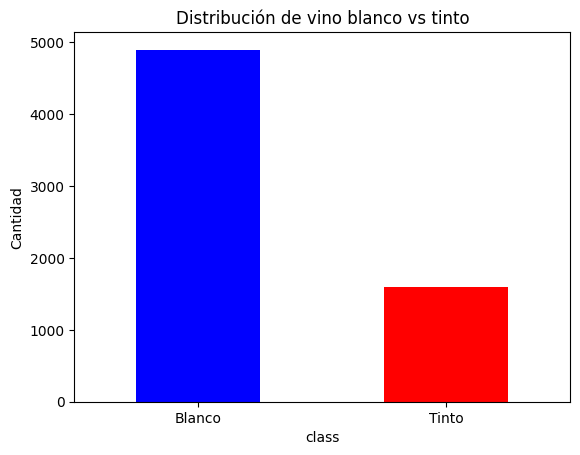

In [31]:
# Distribución de vino blanco vs tinto 
df["class"].value_counts().plot(kind="bar", color=["blue", "red"])
plt.title("Distribución de vino blanco vs tinto")
plt.xticks([0, 1], ["Blanco", "Tinto"], rotation=0)
plt.ylabel("Cantidad")
plt.show()

- Split Train / Test

In [27]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

print("Tamaño train:", train_set.shape)
print("Tamaño test:", test_set.shape)

Tamaño train: (5197, 13)
Tamaño test: (1300, 13)


- Mini EDA
    - Analizo las variables para entender cuáles son más útiles para cada uno de los dos problemas.
    - La variable "class" es categórica (blanco o tinto) y la convertiré a numérica: white = 1, red = 0.

In [28]:
train_set["class"] = (train_set["class"] == "white").astype(int)
test_set["class"] = (test_set["class"] == "white").astype(int)

print(train_set["class"].value_counts())

class
1    3907
0    1290
Name: count, dtype: int64


- Me sale:
    - 3.907 vinos blancos (clase 1)
    - 1.290 vinos tintos (clase 0)
    - Conclusion: Hay más vinos blancos que tintos en el dataset.

In [32]:
print(test_set["class"].value_counts())

class
1    991
0    309
Name: count, dtype: int64


In [33]:
print("Correlación con quality:")
print(df.corr(numeric_only=True)[target_clf].sort_values(ascending=False))

print("\nCorrelación con alcohol:")
print(df.corr(numeric_only=True)[target_reg].sort_values(ascending=False))

Correlación con quality:
quality                 1.000000
alcohol                 0.444319
citric acid             0.085532
free sulfur dioxide     0.055463
sulphates               0.038485
pH                      0.019506
residual sugar         -0.036980
total sulfur dioxide   -0.041385
fixed acidity          -0.076743
chlorides              -0.200666
volatile acidity       -0.265699
density                -0.305858
Name: quality, dtype: float64

Correlación con alcohol:
alcohol                 1.000000
quality                 0.444319
pH                      0.121248
sulphates              -0.003029
citric acid            -0.010493
volatile acidity       -0.037640
fixed acidity          -0.095452
free sulfur dioxide    -0.179838
chlorides              -0.256916
total sulfur dioxide   -0.265740
residual sugar         -0.359415
density                -0.686745
Name: alcohol, dtype: float64


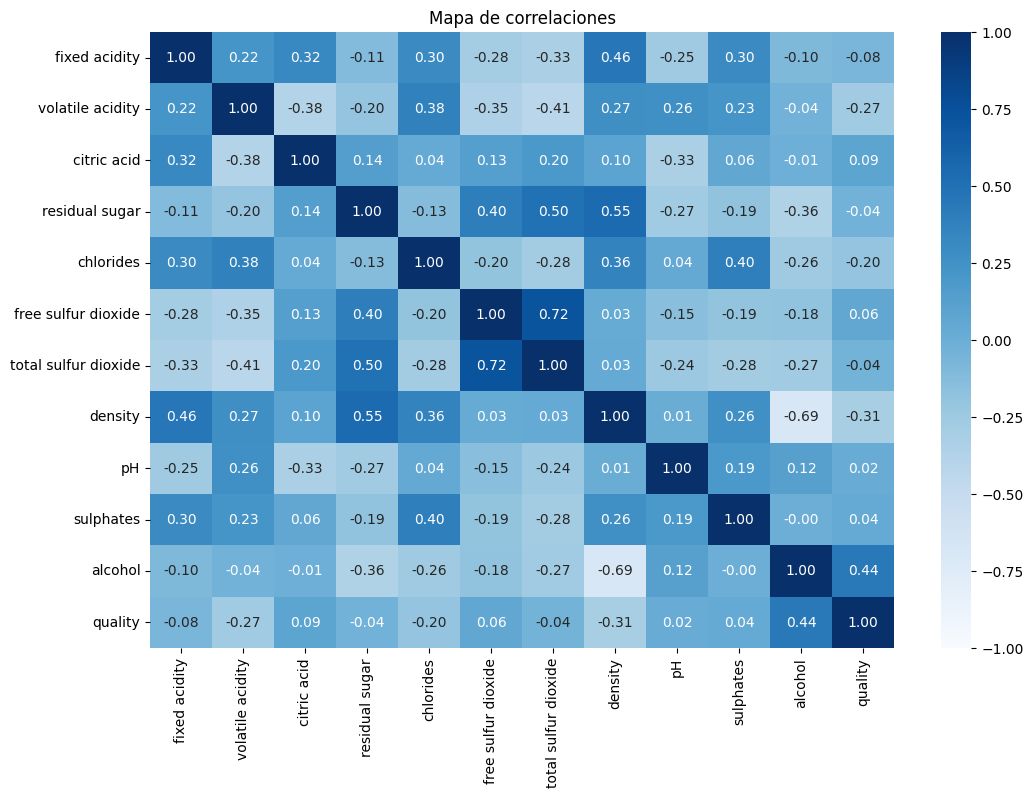

In [35]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), 
            annot=True, 
            fmt=".2f",
            cmap="Blues", 
            vmin=-1, 
            vmax=1)
plt.title("Mapa de correlaciones")
plt.show()

- Las correlaciones más importantes son:

- Para quality:
    - alcohol (0.44): más alcohol = mejor calidad
    - density (-0.31): más densidad = peor calidad
    - volatile acidity (-0.27): más acidez = peor calidad

- Para predecir alcohol:
    - density (-0.69): correlación muy fuerte, a más densidad menos alcohol
    - residual sugar (-0.36): más azúcar = menos alcohol
    - quality (0.44): mejor calidad = más alcohol

In [29]:
# Selección de features
features_clas = [col for col in train_set.columns if col != target_clf]

# Features para regresión  
features_reg = [col for col in train_set.columns if col != target_reg]

print("Features clasificación:", features_clas)
print("\nFeatures regresión:", features_reg)

Features clasificación: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'class']

Features regresión: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'quality', 'class']


- Detalles de las features:
    - Clasificación: 12 features, incluye alcohol pero NO quality
    - Regresión: 12 features, incluye quality pero NO alcohol

In [30]:
scaler = StandardScaler()

# Escalado para clasificación
x_train_clas = train_set[features_clas].copy()
x_test_clas = test_set[features_clas].copy()

x_train_clas_esc = scaler.fit_transform(x_train_clas)
x_test_clas_esc = scaler.transform(x_test_clas)

# Escalado para regresión
x_train_reg = train_set[features_reg].copy()
x_test_reg = test_set[features_reg].copy()

x_train_reg_esc = scaler.fit_transform(x_train_reg)
x_test_reg_esc = scaler.transform(x_test_reg)

# Targets
y_train_clas = train_set[target_clf]
y_test_clas = test_set[target_clf]

y_train_reg = train_set[target_reg]
y_test_reg = test_set[target_reg]

print("Escalado completado")

Escalado completado


### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

In [36]:
# Baseline KNN
knn_5 = KNeighborsClassifier(n_neighbors=5)
knn_10 = KNeighborsClassifier(n_neighbors=10)

score_5 = np.mean(cross_val_score(knn_5, x_train_clas_esc, y_train_clas, cv=5, scoring="balanced_accuracy"))
score_10 = np.mean(cross_val_score(knn_10, x_train_clas_esc, y_train_clas, cv=5, scoring="balanced_accuracy"))

print(f"KNN K=5: {score_5:.3f}")
print(f"KNN K=10: {score_10:.3f}")

KNN K=5: 0.263
KNN K=10: 0.248


Los resultados son muy bajos porque el dataset está muy desbalanceado.
K=5 es ligeramente mejor que K=10, así que lo usaré como baseline.

In [38]:
# Comparativa de modelos
modelos = {
    "KNN_5": KNeighborsClassifier(n_neighbors=5),
    "KNN_10": KNeighborsClassifier(n_neighbors=10),
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(max_depth=10, random_state=42),
    "LightGBM": LGBMClassifier(max_depth=10, random_state=42, verbose=-1)
}

for nombre, modelo in modelos.items():
    if nombre in ["KNN_5", "KNN_10", "Logistic"]:
        score = np.mean(cross_val_score(modelo, x_train_clas_esc, y_train_clas, cv=5, scoring="balanced_accuracy"))
    else:
        score = np.mean(cross_val_score(modelo, x_train_clas, y_train_clas, cv=5, scoring="balanced_accuracy"))
    print(f"{nombre}: {score:.3f}")

KNN_5: 0.263
KNN_10: 0.248
Logistic: 0.226
RandomForest: 0.272
LightGBM: 0.337


Todos los modelos tienen resultados muy bajos debido al desbalance del dataset. LightGBM es el mejor con 0.337.

In [39]:
modelos_cw = {
    "KNN_5": KNeighborsClassifier(n_neighbors=5, weights="distance"),
    "KNN_10": KNeighborsClassifier(n_neighbors=10, weights="distance"),
    "Logistic": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(max_depth=10, random_state=42, class_weight="balanced"),
    "LightGBM": LGBMClassifier(max_depth=10, random_state=42, verbose=-1, class_weight="balanced")
}

for nombre, modelo in modelos_cw.items():
    if nombre in ["KNN_5", "KNN_10", "Logistic"]:
        score = np.mean(cross_val_score(modelo, x_train_clas_esc, y_train_clas, cv=5, scoring="balanced_accuracy"))
    else:
        score = np.mean(cross_val_score(modelo, x_train_clas, y_train_clas, cv=5, scoring="balanced_accuracy"))
    print(f"{nombre}: {score:.3f}")

KNN_5: 0.345
KNN_10: 0.337
Logistic: 0.383
RandomForest: 0.345
LightGBM: 0.359


- Todos los modelos mejoran con class_weight="balanced".
- Logistic Regression es el mejor con 0.383,
- El segundo mejor es el LightGBM con 0.359.

- Selecciono Logistic Regression porque tiene el mejor recall medio (0.383). Es el modelo que mejor detectatodas las clases de calidad de forma equilibrada.

In [41]:
# Optimizar Logistic Regression con GridSearchCV

import warnings
warnings.filterwarnings("ignore")

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "class_weight": ["balanced"],
    "solver": ["lbfgs", "saga"]
}

lr = LogisticRegression(max_iter=1000)

lr_grid = GridSearchCV(lr,
                       param_grid=param_grid,
                       cv=5,
                       scoring="balanced_accuracy",
                       n_jobs=-1)

lr_grid.fit(x_train_clas_esc, y_train_clas)

print("Mejores hiperparámetros:", lr_grid.best_params_)
print("Mejor score:", round(lr_grid.best_score_, 3))

Mejores hiperparámetros: {'C': 10, 'class_weight': 'balanced', 'solver': 'lbfgs'}
Mejor score: 0.387


- Todos los modelos mejoran al usar class_weight="balanced" porque el modelo penaliza más los errores en las clases minoritarias 
(calidades 3, 4, 8 y 9) en vez de centrarse solo en las más frecuentes.

- Seleccionamos Logistic Regression (0.383) porque:
    - Tiene el mejor recall medio de todos los modelos probados
    - Aunque 0.383 sigue siendo bajo, es el mejor resultado 

- El bajo resultado general se debe a que predecir la calidad exacta de un vino es muy difícil 

In [42]:
print(classification_report(y_test_clas, lr_grid.best_estimator_.predict(x_test_clas_esc), zero_division=0.0))

              precision    recall  f1-score   support

           3       0.03      0.67      0.05         6
           4       0.11      0.40      0.18        43
           5       0.56      0.45      0.50       432
           6       0.58      0.25      0.35       562
           7       0.29      0.28      0.28       210
           8       0.09      0.38      0.15        47
           9       0.00      0.00      0.00         0

    accuracy                           0.33      1300
   macro avg       0.24      0.35      0.22      1300
weighted avg       0.49      0.33      0.37      1300



- Evaluación contra test
    - El modelo obtiene un recall medio de 0.35 contra datos nuevos.

- Por clases:
    - Clases extremas (3 y 4): recall alto (0.67 y 0.40) pero precisión muy baja que significa muchos falsos positivos
    - Clases centrales (5 y 6): son las más frecuentes pero el recall baja bastante (0.45 y 0.25)
    - Clase 9: no hay ejemplos en el test y por lo tanto no se puede evaluar

- Conclusión:
    - El modelo tiene dificultades porque hay 7 clases muy desbalanceadas.
    - Es especialmente difícil distinguir entre calidades cercanas como 5, 6 y 7 ya que sus características químicas son muy similares.

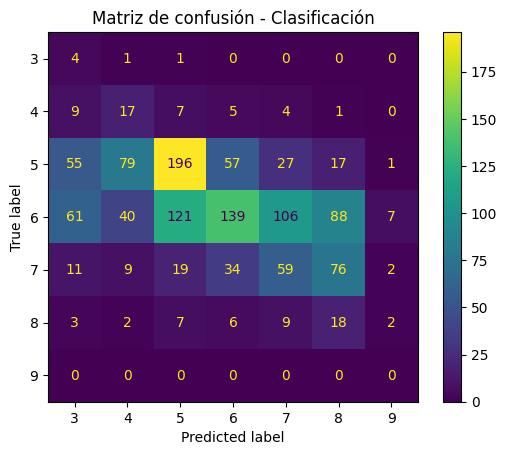

In [43]:
ConfusionMatrixDisplay.from_predictions(y_test_clas, lr_grid.best_estimator_.predict(x_test_clas_esc))
plt.title("Matriz de confusión - Clasificación")
plt.show()

- La clase 5 se predice bien (196 aciertos) pero se confunde mucho con la clase 6 (79 errores)
- La clase 6 es la más difícil (solo 139 aciertos) y se confunde con 5 y 7
- Las clases extremas (3 y 9) casi no se detectan porque hay muy pocos ejemplos
- La mayoría de errores son con modelos de calidades cercanas (5-6, 6-7) lo cual tiene sentido — es difícil distinguir un vino de calidad 6 de uno de calidad 7

- Posibles mejoras:
    - Simplificar las clases: bajo (3-4), medio (5-6-7), alto (8-9)
    - Conseguir más datos de calidades extremas (3, 4, 8, 9)
    - Probar con más features o transformaciones

### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

In [44]:
# Comparativa de modelos de regresión
modelos_reg = {
    "RandomForest": RandomForestRegressor(max_depth=10, random_state=42),
    "LightGBM": LGBMRegressor(max_depth=10, random_state=42, verbose=-1),
    "XGBoost": XGBRegressor(max_depth=10, random_state=42)
}

for nombre, modelo in modelos_reg.items():
    score = -np.mean(cross_val_score(modelo, x_train_reg, y_train_reg, cv=5, scoring="neg_mean_absolute_percentage_error"))
    print(f"{nombre}: {score:.3f}")

RandomForest: 0.031
LightGBM: 0.027
XGBoost: 0.024


- Los tres modelos tienen errores muy bajos (menos del 4%).
- XGBoost es el mejor con solo un 2.4% de error medio.
- Selecciono XGBoost para optimizar sus hiperparámetros.

In [45]:
# OptimizaR XGBoost con GridSearchCV
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10],
    "learning_rate": [0.1, 0.3]
}

xgb = XGBRegressor(random_state=42)

xgb_grid = GridSearchCV(xgb,
                         param_grid=param_grid,
                         cv=5,
                         scoring="neg_mean_absolute_percentage_error",
                         n_jobs=-1)

xgb_grid.fit(x_train_reg, y_train_reg)

print("Mejores hiperparámetros:", xgb_grid.best_params_)
print("Mejor MAPE:", round(-xgb_grid.best_score_, 3))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

Mejores hiperparámetros: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200}
Mejor MAPE: 0.024


- Mejores hiperparámetros encontrados:
    - learning_rate: 0.1
    - max_depth: 10
    - n_estimators: 200

- El modelo mantiene un MAPE de 0.024: solo un 2.4% de error medio.
- Es un buen resultado comparado con la clasificación (recall 0.35)
- En clasificación el modelo falla mucho porque tiene que distinguir entre 7 clases muy parecidas
- En regresión el modelo acierta muy bien porque predecir un número continuo como el alcohol es más sencillo cuando hay variables muy correlacionadas como density (-0.69)

In [46]:
y_pred_reg = xgb_grid.best_estimator_.predict(x_test_reg)
mape = mean_absolute_percentage_error(y_test_reg, y_pred_reg)
print(f"MAPE contra test: {mape:.3f}")

MAPE contra test: 0.022


- Solo un 2.2% de error medio.
- El modelo predice el grado alcohólico con mucha precisión.

- Curiosamente el resultado contra test (0.022) es mejor que en entrenamiento (0.024), lo que indica que el modelo generaliza muy bien y no hay sobreajuste.

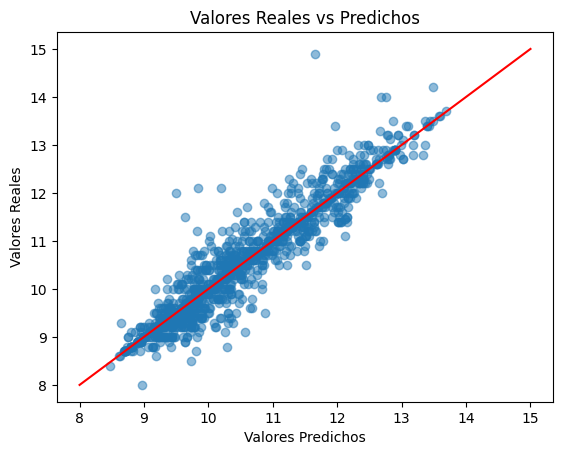

In [47]:
plt.scatter(y_pred_reg, y_test_reg, alpha=0.5)
plt.xlabel("Valores Predichos")
plt.ylabel("Valores Reales")
plt.plot([8, 15], [8, 15], 'r')
plt.title("Valores Reales vs Predichos")
plt.show()